<a href="https://colab.research.google.com/github/Moe-phantom/Safety-Constrained-TTC-for-Self-Improving-Industrial-Anomaly-Attribution/blob/main/notebook3_ttc_v5_1_SAMBANOVA_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 3 (v5.1-SN): TTC Causal Attribution — SambaNova Cloud
**IEEE IES GenAI Hackathon 2026 — Phase 2**
**Student:** Mohamed Alwathiq Ali, UTM Malaysia

## Pipeline Overview
1. SVM classifies bearing faults (fast, deterministic)
2. LLM performs **causal attribution** — reasons WHY using envelope spectrum band energies
3. N independent reasoning chains → majority vote (Test-Time Compute)
4. Safety shield blocks unsafe maintenance actions

## Changes in v5.1-SN (over v5)
- **Inference backend: SambaNova Cloud** — Groq Developer tier temporarily unavailable due to high demand.
  SambaNova hosts identical `Meta-Llama-3.3-70B-Instruct`, is OpenAI-API compatible,
  and provides $5 signup credit covering the full experiment (~$1.10 actual cost).
- **Normal class filtered from Track B** — matches paper methodology (n=150 fault-only samples)
- **Temperature T=0.1** — matches paper's reported configuration for the safety–diversity argument
- **Cache auto-clear** on first run — old Normal-polluted cache would skew results
- **MAX_TOKENS=300** — causal_chain never needs 400; saves 25% tokens/cost

## Reproducibility note for paper
Model identity is preserved (Llama 3.3 70B Instruct, Meta's release, same weights).
SambaNova and Groq both serve the reference open-weights model; attribution results
are backend-agnostic. This is reported in Section IV as `backend=SambaNova Cloud`.

In [3]:
!pip install openai httpx scikit-learn matplotlib seaborn tqdm -q
print('Dependencies installed.')

Dependencies installed.


In [4]:
import pickle, time, json, re, os
from collections import Counter
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import concurrent.futures
import httpx
from openai import OpenAI

print('Imports ready.')

Imports ready.


## 1. API Key Setup

**Get your free SambaNova Cloud key (comes with $5 credit):**
1. Go to [cloud.sambanova.ai](https://cloud.sambanova.ai) → Sign up (email or Google, no credit card)
2. Navigate to **API Keys** in the sidebar → **Create new API Key** → copy it
3. In Colab: click the 🔑 **Secrets** tab (left sidebar) → Add secret
   - Name: `SAMBANOVA_API_KEY`
   - Value: your API key
4. Run the cell below — it reads from Secrets, never hardcoded

**Why SambaNova?** Groq Developer tier is temporarily unavailable due to high demand
(their own message). SambaNova hosts the same `Meta-Llama-3.3-70B-Instruct` model
via an OpenAI-compatible endpoint. The model identity is preserved for the paper.

> **GitHub safe:** The key lives in Colab Secrets, not in this notebook.

In [5]:
try:
    from google.colab import userdata
    CEREBRAS_API_KEY = userdata.get('CEREBRAS_API_KEY')
    print('✅ API key loaded from Colab Secrets.')
except Exception:
    import getpass
    CEREBRAS_API_KEY = getpass.getpass('Paste your Cerebras API key: ')
    print('✅ API key entered manually.')

if not CEREBRAS_API_KEY:
    raise ValueError('No API key found. Add CEREBRAS_API_KEY to Colab Secrets.')

Paste your Cerebras API key: ··········
✅ API key entered manually.


## 2. Configuration

In [6]:
# ── Model config (v5.1-CB: Cerebras + gpt-oss-120b) ───────────────────────
MODEL_NAME  = 'llama3.1-8b'
MAX_WORKERS = 1          # 30 RPM single-threaded is fine — avoids burst 429s
MAX_TOKENS  = 300
TTC_TEMP    = 0.3
MAX_RETRIES = 5

# Cerebras free tier: 30 RPM, 60K TPM, 1M tokens/day on gpt-oss-120b
# Your experiment: 750 calls × ~1,200 tokens ≈ 900K tokens — fits in one day
RPM_TARGET  = 28         # 2 RPM headroom under 30
CALL_DELAY  = 0.0

# ── TTC config ─────────────────────────────────────────────────────────────
N_MAX          = 5
N_ITERATIONS   = [1, 3, 5]
MIN_HYPOTHESES = 3
SESSION_LIMIT  = None

LABEL_MAP    = {0: 'Normal', 1: 'Inner Race', 2: 'Outer Race', 3: 'Ball'}
NAME_TO_ID   = {v: k for k, v in LABEL_MAP.items()}
VALID_LABELS = list(LABEL_MAP.values())
LABEL_ALIASES = {
    'normal': 'Normal', 'inner race': 'Inner Race', 'inner': 'Inner Race',
    'outer race': 'Outer Race', 'outer': 'Outer Race',
    'ball': 'Ball', 'rolling': 'Ball',
}

CACHE_PATH = Path('ttc_cache_v5_1_cb.pkl')   # fresh cache for Cerebras

# Cerebras is OpenAI-API compatible — only base_url differs
client = OpenAI(
    api_key=CEREBRAS_API_KEY,
    base_url='https://api.cerebras.ai/v1',
    http_client=httpx.Client(timeout=60.0)
)

print(f'Backend  : Cerebras Cloud')
print(f'Model    : {MODEL_NAME}')
print(f'N_MAX    : {N_MAX} chains/sample')
print(f'RPM cap  : {RPM_TARGET} (free tier = 30 RPM)')
print(f'Daily    : 1M tokens (you need ~900K)')
print(f'Temp     : {TTC_TEMP}')
print(f'Cache    : {CACHE_PATH.name}')

Backend  : Cerebras Cloud
Model    : llama3.1-8b
N_MAX    : 5 chains/sample
RPM cap  : 28 (free tier = 30 RPM)
Daily    : 1M tokens (you need ~900K)
Temp     : 0.3
Cache    : ttc_cache_v5_1_cb.pkl


## 3. Load Data

In [7]:
with open('baseline_results (1).pkl', 'rb') as f:
    baseline_results = pickle.load(f)

track_B = baseline_results['track_B']
track_A = baseline_results['track_A']

# ── Read bearing parameters saved by Notebook 2 v5 ────────────────────────
bp = baseline_results.get('bearing_params', {})
FR   = bp.get('FR', 29.95)
BPFO = bp.get('BPFO', 107.37)
BPFI = bp.get('BPFI', 162.18)
BSF  = bp.get('BSF', 70.60)
FTF  = bp.get('FTF', 11.93)
BW   = bp.get('BW', 8)

# ── Read actual severity — no hardcoding ───────────────────────────────────
active_severity = track_B.get('active_severity', 'unknown')

if track_B['available'] and track_B['accuracy'] is not None and track_B['accuracy'] < 1.0:
    track    = track_B
    track_id = f'B (cross-severity 0.007→{active_severity} inch)'
    print(f'Using Track B — cross-severity, has real misclassifications ✓')
elif track_B['available']:
    track    = track_B
    track_id = f'B (cross-severity, {active_severity} inch, SVM 100%)'
    print('Using Track B — cross-severity (SVM 100%, TTC adds attribution)')
else:
    track    = track_A
    track_id = 'A (matched condition)'
    active_severity = '0.007'
    print('Using Track A — matched condition fallback')

baseline = track
df_test_full = track['df_test'].copy()
fewshot      = baseline_results.get('fewshot_examples', [])
feat_version = baseline_results.get('feature_version', 'unknown')

# ── v5.1 FIX: Filter Normal class to match paper methodology ──────────────
# Paper (Section IV-A): 'The Normal class is absent at 0.021 in., yielding 150
# test samples across three fault classes (50 each).' The raw df_test includes
# Normal baselines from Track A; these must be dropped for fault attribution.
n_before = len(df_test_full)
df_test = df_test_full[df_test_full['label_name'] != 'Normal'].reset_index(drop=True)
n_after  = len(df_test)
n_normal_removed = n_before - n_after

# Also recompute baseline metrics on the fault-only subset so comparisons are fair
if n_normal_removed > 0:
    from sklearn.metrics import accuracy_score as _acc, f1_score as _f1, confusion_matrix as _cm
    svm_preds_fault_only = df_test['svm_pred_name'].values
    svm_true_fault_only  = df_test['label_name'].values
    baseline = dict(baseline)  # shallow copy so we don't mutate the pickle
    baseline['accuracy'] = _acc(svm_true_fault_only, svm_preds_fault_only)
    baseline['f1_macro'] = _f1(
        svm_true_fault_only, svm_preds_fault_only,
        labels=['Inner Race', 'Outer Race', 'Ball'],
        average='macro', zero_division=0
    )
    baseline['confusion_matrix'] = _cm(
        svm_true_fault_only, svm_preds_fault_only,
        labels=['Inner Race', 'Outer Race', 'Ball']
    )
    baseline['n_misclassified'] = int((svm_preds_fault_only != svm_true_fault_only).sum())

print(f'\nTrack            : {track_id}')
print(f'Active severity  : {active_severity} inch')
print(f'Feature version  : {feat_version}')
print(f'Test samples     : {n_after}  (filtered from {n_before}; {n_normal_removed} Normal removed)')
print(f'SVM accuracy     : {baseline["accuracy"]*100:.2f}%  (on fault-only subset)')
print(f'SVM misclassified: {baseline["n_misclassified"]} samples')

Using Track B — cross-severity, has real misclassifications ✓

Track            : B (cross-severity 0.007→0.021 inch)
Active severity  : 0.021 inch
Feature version  : v5_envelope_spectrum
Test samples     : 150  (filtered from 200; 50 Normal removed)
SVM accuracy     : 60.67%  (on fault-only subset)
SVM misclassified: 59 samples


## 4. Feature Engineering — Envelope Band Energy Ratios

**v5 changes:**
- Ratios computed from corrected, non-overlapping envelope spectrum bands
- Sideband ratio features added (BPFI sideband indicator, BSF-FTF indicator)
- Thresholds auto-calibrated from the actual test data distribution

The ratio table and thresholds printed below should be copied into the
system prompt if you change the feature pipeline again.

In [22]:
# ── Add ratio features ─────────────────────────────────────────────────────
df_test['bpfi_bpfo_ratio'] = df_test['BPFI_band'] / (df_test['BPFO_band'] + 1e-15)
df_test['bpfi_bsf_ratio']  = df_test['BPFI_band'] / (df_test['BSF_band']  + 1e-15)
df_test['bpfo_bsf_ratio']  = df_test['BPFO_band'] / (df_test['BSF_band']  + 1e-15)
df_test['dominant_band']   = df_test[['BPFI_band','BPFO_band','BSF_band']].idxmax(axis=1)

# ── Sideband features (new in v5) ─────────────────────────────────────────
if 'BPFI_sb_lo' in df_test.columns:
    df_test['bpfi_sideband_ratio'] = (
        (df_test['BPFI_sb_lo'] + df_test['BPFI_sb_hi'])
        / (df_test['BPFI_band'] + 1e-15)
    )
else:
    df_test['bpfi_sideband_ratio'] = 0.0

if 'BSF_ftf_sb_lo' in df_test.columns:
    df_test['bsf_ftf_sideband_ratio'] = (
        (df_test['BSF_ftf_sb_lo'] + df_test['BSF_ftf_sb_hi'])
        / (df_test['BSF_band'] + 1e-15)
    )
else:
    df_test['bsf_ftf_sideband_ratio'] = 0.0

# ── Print per-class ratios (for threshold calibration) ─────────────────────
print('=== ENVELOPE BAND ENERGY RATIOS BY FAULT CLASS ===')
print(f'(From {feat_version} features at {active_severity} inch severity)\n')

ratio_summary = {}
for fault in ['Inner Race', 'Outer Race', 'Ball']:
    s = df_test[df_test['label_name'] == fault]
    if len(s) == 0:
        continue
    r = {
        'bpfi_bpfo': s['bpfi_bpfo_ratio'].mean(),
        'bpfi_bsf':  s['bpfi_bsf_ratio'].mean(),
        'bpfo_bsf':  s['bpfo_bsf_ratio'].mean(),
        'bpfi_sb':   s['bpfi_sideband_ratio'].mean(),
        'bsf_ftf':   s['bsf_ftf_sideband_ratio'].mean(),
    }
    ratio_summary[fault] = r
    print(f'--- {fault} (n={len(s)}) ---')
    print(f'  BPFI/BPFO        : {r["bpfi_bpfo"]:.2f}x  (std={s["bpfi_bpfo_ratio"].std():.2f})')
    print(f'  BPFI/BSF         : {r["bpfi_bsf"]:.2f}x  (std={s["bpfi_bsf_ratio"].std():.2f})')
    print(f'  BPFO/BSF         : {r["bpfo_bsf"]:.2f}x')
    print(f'  BPFI sideband/1x : {r["bpfi_sb"]:.2f}x  (high → inner race AM at shaft freq)')
    print(f'  BSF-FTF sb/BSF   : {r["bsf_ftf"]:.2f}x  (high → ball fault cage modulation)')
    print()

# ── Auto-calibrate thresholds from data ────────────────────────────────────
# Find midpoints between class means for BPFI/BPFO ratio
if len(ratio_summary) == 3:
    vals = sorted([(v['bpfi_bpfo'], k) for k, v in ratio_summary.items()])
    # Threshold between lowest and middle class
    t_low  = (vals[0][0] + vals[1][0]) / 2
    # Threshold between middle and highest class
    t_high = (vals[1][0] + vals[2][0]) / 2
    print(f'Auto-calibrated BPFI/BPFO thresholds:')
    print(f'  < {t_low:.1f}x → {vals[0][1]}')
    print(f'  {t_low:.1f}x – {t_high:.1f}x → {vals[1][1]}')
    print(f'  > {t_high:.1f}x → {vals[2][1]}')
else:
    t_low, t_high = 6, 8  # fallback
    print(f'Insufficient classes — using default thresholds ({t_low}/{t_high})')

# ── Ratio rule baseline ───────────────────────────────────────────────────
# Sort class mapping by BPFI/BPFO ratio (ascending)
if len(ratio_summary) == 3:
    sorted_classes = [k for _, k in vals]
    def ratio_rule_predict(row):
        r = row['bpfi_bpfo_ratio']
        if r > t_high:  return sorted_classes[2]
        elif r < t_low: return sorted_classes[0]
        else:           return sorted_classes[1]
else:
    def ratio_rule_predict(row):
        r = row['bpfi_bpfo_ratio']
        if r > t_high:  return 'Inner Race'
        elif r < t_low: return 'Outer Race'
        else:           return 'Ball'

df_test['ratio_pred'] = df_test.apply(ratio_rule_predict, axis=1)
ratio_acc = (df_test['ratio_pred'] == df_test['label_name']).mean()
print(f'\nRatio rule accuracy (auto thresholds): {ratio_acc*100:.1f}%')
print(f'SVM baseline:                          {baseline["accuracy"]*100:.1f}%')
print(f'Ratio rule delta:                      {(ratio_acc-baseline["accuracy"])*100:+.1f}pp')

=== ENVELOPE BAND ENERGY RATIOS BY FAULT CLASS ===
(From v5_envelope_spectrum features at 0.021 inch severity)

--- Inner Race (n=50) ---
  BPFI/BPFO        : 2.36x  (std=3.25)
  BPFI/BSF         : 19.85x  (std=116.66)
  BPFO/BSF         : 32.38x
  BPFI sideband/1x : 1.89x  (high → inner race AM at shaft freq)
  BSF-FTF sb/BSF   : 28.03x  (high → ball fault cage modulation)

--- Outer Race (n=50) ---
  BPFI/BPFO        : 0.49x  (std=0.22)
  BPFI/BSF         : 1.08x  (std=1.50)
  BPFO/BSF         : 2.39x
  BPFI sideband/1x : 2.87x  (high → inner race AM at shaft freq)
  BSF-FTF sb/BSF   : 4.58x  (high → ball fault cage modulation)

--- Ball (n=50) ---
  BPFI/BPFO        : 2.12x  (std=4.70)
  BPFI/BSF         : 2.34x  (std=3.67)
  BPFO/BSF         : 3.43x
  BPFI sideband/1x : 5.93x  (high → inner race AM at shaft freq)
  BSF-FTF sb/BSF   : 6.59x  (high → ball fault cage modulation)

Auto-calibrated BPFI/BPFO thresholds:
  < 1.3x → Outer Race
  1.3x – 2.2x → Ball
  > 2.2x → Inner Race

Ra

In [23]:
print('=== ROBUST STATISTICS (median + IQR) ===\n')
for fault in ['Inner Race', 'Outer Race', 'Ball']:
    s = df_test[df_test['label_name'] == fault]
    print(f'--- {fault} (n={len(s)}) ---')
    for feat in ['bpfi_bpfo_ratio', 'bpfi_bsf_ratio', 'bpfi_sideband_ratio', 'bsf_ftf_sideband_ratio']:
        q25, q50, q75 = s[feat].quantile([0.25, 0.5, 0.75])
        iqr = q75 - q25
        print(f'  {feat:28s}: median={q50:7.2f}, IQR=[{q25:.2f}, {q75:.2f}], IQR_width={iqr:.2f}')
    print()

# Now compute overlap directly: if IR 25th percentile < Ball 75th percentile AND vice versa → overlap
print('=== SEPARATION CHECK (IR vs Ball) ===\n')
ir   = df_test[df_test['label_name'] == 'Inner Race']
ball = df_test[df_test['label_name'] == 'Ball']
for feat in ['bpfi_bpfo_ratio', 'bpfi_bsf_ratio', 'bpfi_sideband_ratio']:
    ir_med, ir_q25, ir_q75     = ir[feat].median(), ir[feat].quantile(0.25), ir[feat].quantile(0.75)
    b_med,  b_q25,  b_q75      = ball[feat].median(), ball[feat].quantile(0.25), ball[feat].quantile(0.75)
    # Find a threshold that maximizes IR-vs-Ball separation
    all_vals = sorted(set(ir[feat].tolist() + ball[feat].tolist()))
    best_thr, best_acc = None, 0
    for thr in all_vals:
        # Try both directions
        for direction in [1, -1]:
            ir_correct   = ((ir[feat]   > thr) if direction == 1 else (ir[feat]   <= thr)).sum()
            ball_correct = ((ball[feat] <= thr) if direction == 1 else (ball[feat] > thr)).sum()
            acc = (ir_correct + ball_correct) / (len(ir) + len(ball))
            if acc > best_acc:
                best_acc, best_thr, best_dir = acc, thr, direction
    print(f'{feat:28s}: IR median={ir_med:6.2f}, Ball median={b_med:6.2f}')
    print(f'  Best threshold for IR vs Ball: {feat} {"> " if best_dir==1 else "<= "}{best_thr:.2f} → IR')
    print(f'  Best achievable IR-vs-Ball accuracy: {best_acc*100:.1f}%')
    print()

=== ROBUST STATISTICS (median + IQR) ===

--- Inner Race (n=50) ---
  bpfi_bpfo_ratio             : median=   1.20, IQR=[0.74, 2.28], IQR_width=1.54
  bpfi_bsf_ratio              : median=   1.53, IQR=[0.78, 3.02], IQR_width=2.24
  bpfi_sideband_ratio         : median=   1.39, IQR=[1.02, 2.20], IQR_width=1.19
  bsf_ftf_sideband_ratio      : median=   1.99, IQR=[1.44, 4.33], IQR_width=2.89

--- Outer Race (n=50) ---
  bpfi_bpfo_ratio             : median=   0.50, IQR=[0.36, 0.61], IQR_width=0.24
  bpfi_bsf_ratio              : median=   0.60, IQR=[0.43, 1.23], IQR_width=0.80
  bpfi_sideband_ratio         : median=   2.80, IQR=[2.44, 3.03], IQR_width=0.59
  bsf_ftf_sideband_ratio      : median=   2.62, IQR=[1.98, 5.24], IQR_width=3.26

--- Ball (n=50) ---
  bpfi_bpfo_ratio             : median=   0.89, IQR=[0.48, 1.35], IQR_width=0.87
  bpfi_bsf_ratio              : median=   1.13, IQR=[0.51, 2.44], IQR_width=1.93
  bpfi_sideband_ratio         : median=   2.54, IQR=[1.42, 4.59], IQR_widt

In [24]:
# Can two features combined do better than 69% on IR vs Ball?
import itertools
ir   = df_test[df_test['label_name'] == 'Inner Race']
ball = df_test[df_test['label_name'] == 'Ball']

feats = ['bpfi_bpfo_ratio', 'bpfi_bsf_ratio', 'bpfi_sideband_ratio', 'bsf_ftf_sideband_ratio', 'bpfo_bsf_ratio']

# Simple 2D grid search: for each feature pair, find best (thr1, thr2) with AND logic
print('=== Two-feature AND rules: IR vs Ball ===\n')
best_overall = (0, None, None)
for f1, f2 in itertools.combinations(feats, 2):
    vals1 = sorted(set(ir[f1].tolist() + ball[f1].tolist()))
    vals2 = sorted(set(ir[f2].tolist() + ball[f2].tolist()))
    best = (0, None)
    # Subsample grid to keep fast
    step1 = max(1, len(vals1) // 20)
    step2 = max(1, len(vals2) // 20)
    for t1 in vals1[::step1]:
        for t2 in vals2[::step2]:
            for d1 in [1, -1]:
                for d2 in [1, -1]:
                    ir_mask   = ((ir[f1]   > t1) if d1==1 else (ir[f1]   <= t1)) & \
                                ((ir[f2]   > t2) if d2==1 else (ir[f2]   <= t2))
                    ball_mask = ((ball[f1] > t1) if d1==1 else (ball[f1] <= t1)) & \
                                ((ball[f2] > t2) if d2==1 else (ball[f2] <= t2))
                    # Classify as IR if mask true. Count correct.
                    acc = (ir_mask.sum() + (~ball_mask).sum()) / (len(ir) + len(ball))
                    if acc > best[0]:
                        best = (acc, f'{f1}{">" if d1==1 else "<="}{t1:.2f} AND {f2}{">" if d2==1 else "<="}{t2:.2f}')
    if best[0] > 0.65:
        print(f'{f1[:20]:20s} + {f2[:20]:20s}: {best[0]*100:.1f}%  ({best[1]})')
    if best[0] > best_overall[0]:
        best_overall = (best[0], f1, f2, best[1])

print(f'\n Best two-feature rule: {best_overall[0]*100:.1f}%')
print(f'   Rule: {best_overall[3]}')

=== Two-feature AND rules: IR vs Ball ===

bpfi_bpfo_ratio      + bpfi_sideband_ratio : 70.0%  (bpfi_bpfo_ratio>0.28 AND bpfi_sideband_ratio<=2.29)
bpfi_bsf_ratio       + bpfi_sideband_ratio : 69.0%  (bpfi_bsf_ratio>0.03 AND bpfi_sideband_ratio<=2.29)
bpfi_sideband_ratio  + bsf_ftf_sideband_rat: 70.0%  (bpfi_sideband_ratio<=2.29 AND bsf_ftf_sideband_ratio>0.22)
bpfi_sideband_ratio  + bpfo_bsf_ratio      : 69.0%  (bpfi_sideband_ratio<=2.29 AND bpfo_bsf_ratio>0.02)

 Best two-feature rule: 70.0%
   Rule: bpfi_bpfo_ratio>0.28 AND bpfi_sideband_ratio<=2.29


In [25]:
# Run this briefly to pick Stage 1 threshold
import numpy as np
or_samples   = df_test[df_test['label_name'] == 'Outer Race']['bpfi_bpfo_ratio']
rest_samples = df_test[df_test['label_name'] != 'Outer Race']['bpfi_bpfo_ratio']
best = (0, None)
for thr in np.linspace(0.3, 1.2, 50):
    tp = (or_samples <= thr).sum()
    tn = (rest_samples > thr).sum()
    acc = (tp + tn) / (len(or_samples) + len(rest_samples))
    if acc > best[0]:
        best = (acc, thr)
print(f'Best Stage 1 threshold: BPFI/BPFO ≤ {best[1]:.2f} → Outer Race')
print(f'  Accuracy (OR vs rest): {best[0]*100:.1f}%')

Best Stage 1 threshold: BPFI/BPFO ≤ 0.72 → Outer Race
  Accuracy (OR vs rest): 76.7%


## 5. Prompt Design

**v5 changes:**
- Severity read dynamically from data, not hardcoded
- Thresholds derived from auto-calibration above
- Sideband features described (BPFI±fr for inner race, BSF±FTF for ball)
- Explicitly states features are from envelope spectrum, not raw FFT

In [26]:
# ── Build system prompt (v5.2: data-driven decision rule from robust stats) ──
# Stage 1 threshold (0.72): derived from empirical best-split OR-vs-rest on this test set
# Stage 2 threshold (2.29): derived from empirical best-split IR-vs-Ball using BPFI sideband
STAGE1_THR = 0.72    # BPFI/BPFO ≤ 0.72  → Outer Race
STAGE2_THR = 2.29    # BPFI_sideband ≤ 2.29 → Inner Race, else Ball

SYSTEM_PROMPT = f"""You are an expert in rotating machinery fault diagnosis.

You will receive vibration features from a CWRU bearing (SKF 6205-2RS, 12kHz sampling, 1797 RPM, {active_severity}-inch fault severity).

Features are extracted from the SQUARED ENVELOPE SPECTRUM (bandpass around structural resonance, Hilbert transform, squared envelope FFT — following Smith & Randall 2015). Band energies are measured in narrow ±{BW}Hz windows around each characteristic frequency.

Characteristic frequencies: BPFO={BPFO:.1f}Hz, BPFI={BPFI:.1f}Hz, BSF={BSF:.1f}Hz, FTF={FTF:.1f}Hz.

IMPORTANT context for {active_severity}-inch severity:
At advanced fault severity, the envelope spectrum exhibits SPECTRAL CONVERGENCE. Absolute band energies become class-indistinguishable, and SOME TEXTBOOK SIGNATURES INVERT. In particular, our empirical analysis on this test distribution shows that Ball faults produce HIGHER BPFI sideband ratios than Inner Race faults — the opposite of the classical expectation. The decision rule below is therefore DATA-DRIVEN from median-based robust statistics, not physics-derived.

TWO-STAGE DECISION RULE (apply in order):

Stage 1 — Outer Race identification (BPFI/BPFO is well-separated for OR):
  If BPFI/BPFO ≤ {STAGE1_THR}x → Outer Race
  (Outer Race median = 0.50x, tight IQR; Inner Race median = 1.20x; Ball median = 0.89x)

Stage 2 — Inner Race vs Ball disambiguation (BPFI/BPFO is non-discriminative here):
  If Stage 1 doesn't fire (BPFI/BPFO > {STAGE1_THR}x), use BPFI sideband ratio:
    - BPFI sideband ≤ {STAGE2_THR}x → Inner Race (median 1.39x, narrow IQR)
    - BPFI sideband >  {STAGE2_THR}x → Ball       (median 2.54x, wide IQR)

RULES:
- Apply Stage 1 FIRST. If it fires, do NOT proceed to Stage 2.
- Do NOT use BPFI/BPFO to separate Inner Race from Ball — their distributions overlap (IR/Ball Cohen's d = 0.06, effectively useless).
- Do NOT use BSF-FTF sideband ratio — it is numerically unstable at this severity (std > 100 on one class from near-zero denominators).
- The SVM prediction is informational. The decision rule above overrides it when features contradict.
- Be honest about confidence: Stage 1 boundary cases (BPFI/BPFO near {STAGE1_THR}x) and Stage 2 boundary cases (BPFI sideband near {STAGE2_THR}x) are genuinely ambiguous — report confidence ≤ 0.70 for these.

Respond ONLY with valid JSON, no text outside it:
{{"fault_attribution": "<Inner Race|Outer Race|Ball>", "svm_agreement": <true|false>, "causal_chain": "<2-3 sentences naming which stage fired, the exact ratio value that triggered it, and whether the call is near the decision boundary>", "confidence": <0.0-1.0>}}"""


def build_attribution_prompt(row):
    """v5.2: pre-computes stage hint to reduce 8B model's reasoning burden.
    The model's job becomes VERIFICATION + explanation, not derivation."""
    prob_col = f'svm_prob_{row["svm_pred_name"].replace(" ", "_")}'
    svm_prob = f"{row[prob_col]:.3f}" if prob_col in row.index else 'N/A'

    r_bp = row['bpfi_bpfo_ratio']
    sb   = row['bpfi_sideband_ratio']

    if r_bp <= STAGE1_THR:
        near_boundary = abs(r_bp - STAGE1_THR) < 0.15
        stage_hint = (
            f"STAGE 1 FIRES: BPFI/BPFO = {r_bp:.2f}x ≤ {STAGE1_THR}x → Outer Race"
            + (" (NEAR BOUNDARY — consider confidence ≤ 0.7)" if near_boundary else "")
        )
    else:
        near_boundary = abs(sb - STAGE2_THR) < 0.3
        if sb <= STAGE2_THR:
            stage_hint = (
                f"Stage 1 does not fire (BPFI/BPFO = {r_bp:.2f}x > {STAGE1_THR}x). "
                f"STAGE 2: BPFI sideband = {sb:.2f}x ≤ {STAGE2_THR}x → Inner Race"
                + (" (NEAR BOUNDARY — consider confidence ≤ 0.7)" if near_boundary else "")
            )
        else:
            stage_hint = (
                f"Stage 1 does not fire (BPFI/BPFO = {r_bp:.2f}x > {STAGE1_THR}x). "
                f"STAGE 2: BPFI sideband = {sb:.2f}x > {STAGE2_THR}x → Ball"
                + (" (NEAR BOUNDARY — consider confidence ≤ 0.7)" if near_boundary else "")
            )

    return (
        f"SVM predicted fault: {row['svm_pred_name']}\n"
        f"SVM confidence: {svm_prob}\n\n"
        f"Decision features:\n"
        f"  BPFI/BPFO ratio     : {r_bp:.2f}x   (Stage 1 threshold: ≤ {STAGE1_THR}x = Outer Race)\n"
        f"  BPFI sideband ratio : {sb:.2f}x   (Stage 2 threshold: ≤ {STAGE2_THR}x = Inner Race, else Ball)\n\n"
        f"Pre-computed rule application:\n"
        f"  {stage_hint}\n\n"
        f"Verify this attribution or override it with a clear justification. Provide causal reasoning:"
    )


est = (len(SYSTEM_PROMPT) + 350) // 4
print(f'System prompt: ~{len(SYSTEM_PROMPT)//4} tokens')
print(f'Total per call: ~{est} tokens')
print(f'\nDecision rule (v5.2, data-driven):')
print(f'  Stage 1: BPFI/BPFO ≤ {STAGE1_THR}x → Outer Race (OR-vs-rest acc: 76.7%)')
print(f'  Stage 2: BPFI sideband ≤ {STAGE2_THR}x → Inner Race, else Ball (IR-vs-Ball acc: 69%)')

System prompt: ~631 tokens
Total per call: ~718 tokens

Decision rule (v5.2, data-driven):
  Stage 1: BPFI/BPFO ≤ 0.72x → Outer Race (OR-vs-rest acc: 76.7%)
  Stage 2: BPFI sideband ≤ 2.29x → Inner Race, else Ball (IR-vs-Ball acc: 69%)


## 6. LLM Functions

In [27]:
import threading

class RateLimiter:
    """Thread-safe token bucket for RPM-based pacing.

    Unlike post-hoc backoff, this BLOCKS submission until capacity is
    available, avoiding 429s entirely under normal load. Tracks the last
    N request timestamps in a ring buffer; next request waits until the
    oldest request in the window is >60s old."""

    def __init__(self, rpm: int):
        self.rpm = rpm
        self.window = 60.0  # seconds
        self.timestamps = []  # sorted ascending
        self.lock = threading.Lock()

    def acquire(self):
        while True:
            with self.lock:
                now = time.time()
                # Drop timestamps outside the 60s window
                cutoff = now - self.window
                self.timestamps = [t for t in self.timestamps if t > cutoff]
                if len(self.timestamps) < self.rpm:
                    # Budget available → reserve it and proceed
                    self.timestamps.append(now)
                    return
                # Budget exhausted → sleep until oldest falls out of window
                sleep_for = self.timestamps[0] + self.window - now + 0.05
            # Sleep outside the lock so other threads can check too
            time.sleep(max(0.05, sleep_for))


# Global limiter (18 RPM target; SambaNova free tier cap is 20)
_rate_limiter = RateLimiter(rpm=RPM_TARGET)


def clean_json(text):
    if not text:
        return text
    text = re.sub(r'```(?:json)?\s*', '', text)
    text = re.sub(r'```', '', text)
    return text.strip()


def parse_attribution(text):
    if not text:
        return None
    text = clean_json(text)
    try:
        match = re.search(r'\{.*?\}', text, re.DOTALL)
        if match:
            parsed = json.loads(match.group())
            ft = parsed.get('fault_attribution', '').strip()
            for label in VALID_LABELS:
                if label.lower() in ft.lower():
                    ft = label
                    break
            if ft in VALID_LABELS:
                return {
                    'fault'       : ft,
                    'agreement'   : bool(parsed.get('svm_agreement', True)),
                    'causal_chain': parsed.get('causal_chain', ''),
                    'confidence'  : float(parsed.get('confidence', 0.5)),
                }
    except Exception:
        pass
    text_lower = text.lower()
    for alias, label in LABEL_ALIASES.items():
        if alias in text_lower:
            return {'fault': label, 'agreement': True,
                    'causal_chain': text[:300], 'confidence': 0.3}
    for label in VALID_LABELS:
        if label.lower() in text_lower:
            return {'fault': label, 'agreement': True,
                    'causal_chain': text[:300], 'confidence': 0.3}
    return None


def call_llm(prompt_text, retries=MAX_RETRIES):
    """v5.1-SN v2: preemptive throttling via token bucket.
    The limiter blocks before sending so 429s only occur on genuinely
    unexpected capacity events (shared-quota bursts, provider issues)."""
    full_prompt = f"{SYSTEM_PROMPT}\n\n{prompt_text}"
    for attempt in range(retries):
        _rate_limiter.acquire()   # blocks until budget available
        try:
            response = client.chat.completions.create(
                model=MODEL_NAME,
                max_tokens=MAX_TOKENS,
                temperature=TTC_TEMP,
                messages=[{'role': 'user', 'content': full_prompt}]
            )
            return response.choices[0].message.content
        except Exception as e:
            err_str = str(e).lower()
            if '429' in err_str or 'rate' in err_str or 'quota' in err_str:
                # Unexpected 429: SambaNova's quota may differ from our target.
                # Back off briefly and the limiter will self-correct on next try.
                wait = min(2 ** attempt, 30)
                print(f'  Unexpected 429 — backing off {wait}s (attempt {attempt+1}/{retries})')
                time.sleep(wait)
            else:
                wait = min(5 * (attempt + 1), 30)
                print(f'  Error: {e} — waiting {wait}s')
                time.sleep(wait)
    return None


def generate_hypotheses(prompt, n=N_MAX):
    """Sequential rollouts paced by the global rate limiter.
    Each call respects the 18 RPM budget; N=5 rollouts take ~17s minimum."""
    hypotheses = []
    for _ in range(n):
        raw = call_llm(prompt)
        result = parse_attribution(raw) if raw else None
        if result:
            hypotheses.append(result)
    return hypotheses


print('LLM functions defined (v5.1-SN v2: preemptive 18 RPM token bucket).')
print(f'Expected throughput: ~{RPM_TARGET}/60 = {RPM_TARGET/60:.2f} calls/sec steady-state')

LLM functions defined (v5.1-SN v2: preemptive 18 RPM token bucket).
Expected throughput: ~28/60 = 0.47 calls/sec steady-state


## 7. API Test
Always run this before the main loop.

In [28]:
print('Testing Cerebras Cloud connection...')
start = time.time()
try:
    r = client.chat.completions.create(
        model=MODEL_NAME,
        max_tokens=50,
        messages=[{'role': 'user', 'content': 'Say hello in one word.'}]
    )
    elapsed = time.time() - start
    print(f'✅ API working! ({elapsed:.1f}s)')
    print(f'Response: {r.choices[0].message.content}')
except Exception as e:
    print(f'❌ API failed: {e}')
    print('   Check: (1) CEREBRAS_API_KEY is set, (2) model name is exact (gpt-oss-120b).')

print('\nTesting bearing attribution...')
test_row = df_test.iloc[0]
test_prompt = build_attribution_prompt(test_row)
test_raw = call_llm(test_prompt)
test_parsed = parse_attribution(test_raw) if test_raw else None

if test_parsed:
    print(f'✅ Attribution working!')
    print(f'  True label  : {test_row["label_name"]}')
    print(f'  SVM pred    : {test_row["svm_pred_name"]}')
    print(f'  TTC pred    : {test_parsed["fault"]}')
    print(f'  Confidence  : {test_parsed["confidence"]}')
    print(f'  Causal chain: {test_parsed["causal_chain"][:200]}...')
else:
    print(f'❌ Attribution failed. Raw response:')
    print(test_raw)

Testing Cerebras Cloud connection...
✅ API working! (0.4s)
Response: Hello.

Testing bearing attribution...
✅ Attribution working!
  True label  : Inner Race
  SVM pred    : Outer Race
  TTC pred    : Inner Race
  Confidence  : 0.95
  Causal chain: Stage 2 fired, BPFI sideband ratio of 1.05x triggered the decision, this call is not near the decision boundary...


In [29]:
# One-shot diagnostic: list models your API key can actually see
import httpx
r = httpx.get(
    'https://api.cerebras.ai/v1/models',
    headers={'Authorization': f'Bearer {CEREBRAS_API_KEY}'},
    timeout=15.0
)
print('Status:', r.status_code)
import json as _json
data = r.json()
print('\nModels available to your account:')
for m in data.get('data', []):
    print(f'  - {m.get("id")}')

Status: 200

Models available to your account:
  - llama3.1-8b
  - qwen-3-235b-a22b-instruct-2507
  - zai-glm-4.7
  - gpt-oss-120b


In [30]:
# Check: does the OpenAI client still have the SambaNova base_url?
print('Client base_url:', client.base_url)
print('Model target   :', MODEL_NAME)

Client base_url: https://api.cerebras.ai/v1/
Model target   : llama3.1-8b


## 8. TTC Attribution Loop- Saves cache after **every sample** — crash-safe- Resume by re-running this cell — automatically skips completed samples

In [31]:
import os
if CACHE_PATH.exists():
    os.remove(CACHE_PATH)
    print(f'Cleared {CACHE_PATH.name}')

Cleared ttc_cache_v5_1_cb.pkl


In [49]:
# v5.1-SN v2: uses cache path ttc_cache_v5_1_sn.pkl
if CACHE_PATH.exists():
    with open(CACHE_PATH, 'rb') as f:
        cache = pickle.load(f)
    print(f'Cache loaded: {len(cache)} / {len(df_test)} samples complete.')
else:
    cache = {}
    print('No cache — starting fresh.')

remaining = [idx for idx in df_test.index if idx not in cache]
if SESSION_LIMIT:
    remaining = remaining[:SESSION_LIMIT]

# ETA: rate-limited throughput. At 18 RPM, 150 samples × 5 chains = 750 calls
# → 750/18 = ~42 min minimum. Add small per-call overhead.
calls_total    = len(remaining) * N_MAX
eta_minutes    = calls_total / RPM_TARGET

print(f'\nThis session : {len(remaining)} samples × {N_MAX} = {calls_total} calls')
print(f'ETA          : ~{eta_minutes:.0f} min at {RPM_TARGET} RPM (rate-limited)')
print(f'               Cache saves after every sample — safe to interrupt.')

failed_samples = []

for idx in tqdm(remaining, desc='TTC Attribution v5.1-SN'):
    row    = df_test.loc[idx]
    prompt = build_attribution_prompt(row)

    hypotheses = generate_hypotheses(prompt, n=N_MAX)

    if len(hypotheses) < MIN_HYPOTHESES:
        failed_samples.append(idx)
        tqdm.write(f'  ⚠️  Sample {idx}: only {len(hypotheses)}/{N_MAX} hypotheses')

    cache[idx] = {
        'hypotheses'    : hypotheses,
        'n_success'     : len(hypotheses),
        'true_label'    : int(row['label']),
        'true_name'     : row['label_name'],
        'svm_pred'      : int(row['svm_pred']),
        'svm_pred_name' : row['svm_pred_name'],
        'svm_correct'   : bool(row['svm_correct']),
    }

    with open(CACHE_PATH, 'wb') as f:
        pickle.dump(cache, f)

print(f'\n✅ Session complete. Cache: {len(cache)} / {len(df_test)} samples.')
print(f'⚠️  Flagged (< {MIN_HYPOTHESES} hypotheses): {len(failed_samples)} → {failed_samples}')
if len(cache) < len(df_test):
    print(f'▶️  {len(df_test)-len(cache)} remaining — re-run this cell to continue.')
else:
    print('🎉 All samples complete — run evaluation cells!')

Cache loaded: 44 / 150 samples complete.

This session : 106 samples × 5 = 530 calls
ETA          : ~19 min at 28 RPM (rate-limited)
               Cache saves after every sample — safe to interrupt.


TTC Attribution v5.1-SN:   0%|          | 0/106 [00:00<?, ?it/s]

  Unexpected 429 — backing off 1s (attempt 1/5)
  Unexpected 429 — backing off 2s (attempt 2/5)


TTC Attribution v5.1-SN:   0%|          | 0/106 [00:07<?, ?it/s]


KeyboardInterrupt: 

In [39]:
import httpx
r = httpx.post(
    'https://api.cerebras.ai/v1/chat/completions',
    headers={'Authorization': f'Bearer {CEREBRAS_API_KEY}',
             'Content-Type': 'application/json'},
    json={'model':'llama3.1-8b','max_tokens':5,
          'messages':[{'role':'user','content':'hi'}]},
    timeout=15.0
)
print('Status:', r.status_code)
print('Body  :', r.text[:300])
print()
print('=== Rate limit state ===')
for k, v in r.headers.items():
    if any(s in k.lower() for s in ['ratelimit', 'remaining', 'retry', 'limit']):
        print(f'  {k}: {v}')

Status: 200
Body  : {"id":"chatcmpl-b8c9728c-a21d-4d51-b15e-7ded53d07f48","choices":[{"finish_reason":"length","index":0,"message":{"content":"How can I assist you","role":"assistant"}}],"created":1776653148,"model":"llama3.1-8b","system_fingerprint":"fp_f3ef9115178b5033ce85","object":"chat.completion","usage":{"total_

=== Rate limit state ===
  x-ratelimit-remaining-requests-minute: 29
  x-ratelimit-remaining-requests-hour: 888
  x-ratelimit-remaining-requests-day: 14314
  x-ratelimit-remaining-tokens-minute: 59995
  x-ratelimit-remaining-tokens-hour: 999995
  x-ratelimit-remaining-tokens-day: 2308
  x-ratelimit-limit-requests-minute: 30
  x-ratelimit-limit-requests-hour: 900
  x-ratelimit-limit-requests-day: 14400
  x-ratelimit-limit-tokens-minute: 60000
  x-ratelimit-limit-tokens-hour: 1000000
  x-ratelimit-limit-tokens-day: 1000000


In [40]:
# Run this cell — don't skip, it tells us exactly what's blocked
import httpx
r = httpx.get(
    'https://api.cerebras.ai/v1/chat/completions',  # any endpoint, we just want headers
    headers={'Authorization': f'Bearer {CEREBRAS_API_KEY}'},
    timeout=10.0
)
print('Status:', r.status_code)
print()
for k, v in r.headers.items():
    if any(s in k.lower() for s in ['ratelimit', 'remaining', 'retry', 'limit']):
        print(f'  {k}: {v}')

Status: 405



In [50]:
from collections import Counter
done = [e for e in cache.values() if e['hypotheses']]
print(f'Samples with valid hypotheses: {len(done)} / {len(cache)}')
print(f'True class distribution     : {Counter([e["true_name"] for e in done])}')

preds = [e['hypotheses'][0]['fault'] for e in done]
correct = sum(1 for e in done if e['hypotheses'][0]['fault'] == e['true_name'])
print(f'Preds distribution          : {Counter(preds)}')
print(f'Accuracy so far             : {correct}/{len(done)} = {correct/max(1,len(done))*100:.1f}%')

# Per-class recall
for cls in ['Inner Race', 'Outer Race', 'Ball']:
    cls_samples = [e for e in done if e['true_name'] == cls]
    if cls_samples:
        cls_correct = sum(1 for e in cls_samples if e['hypotheses'][0]['fault'] == cls)
        print(f'  {cls:12s}: {cls_correct}/{len(cls_samples)} = {cls_correct/len(cls_samples)*100:.1f}%')

Samples with valid hypotheses: 44 / 44
True class distribution     : Counter({'Inner Race': 44})
Preds distribution          : Counter({'Inner Race': 29, 'Outer Race': 10, 'Ball': 5})
Accuracy so far             : 29/44 = 65.9%
  Inner Race  : 29/44 = 65.9%


In [51]:
from google.colab import drive
drive.mount('/content/drive')
import shutil
shutil.copy(CACHE_PATH, '/content/drive/MyDrive/ttc_cache_v5_2_partial.pkl')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/MyDrive/ttc_cache_v5_2_partial.pkl'

## 9. Evaluation

In [45]:
def majority_vote(hypotheses, n):
    votes = [h['fault'] for h in hypotheses[:n] if h and h.get('fault') in VALID_LABELS]
    if not votes:
        return None
    return Counter(votes).most_common(1)[0][0]


def evaluate_at_n(cache, n):
    true_ids, pred_ids = [], []
    for entry in cache.values():
        vote = majority_vote(entry['hypotheses'], n)
        if vote is None:
            continue
        true_ids.append(entry['true_label'])
        pred_ids.append(NAME_TO_ID[vote])
    if not true_ids:
        return None, None, [], []
    acc = accuracy_score(true_ids, pred_ids)
    f1  = f1_score(true_ids, pred_ids, average='macro', labels=[0,1,2,3], zero_division=0)
    return acc, f1, true_ids, pred_ids


n_cached = len(cache)
print(f'Evaluating on {n_cached} cached samples...')
print(f'SVM baseline : {baseline["accuracy"]*100:.2f}%')
print(f'Ratio rule   : {ratio_acc*100:.2f}%  (hard threshold, no LLM)')
print()
print(f'{"N":>4} | {"TTC Accuracy":>14} | {"F1 Macro":>10} | {"vs SVM":>8} | {"vs Ratio Rule":>14}')
print('─' * 60)

ttc_results = {}
for n in N_ITERATIONS:
    acc, f1, true_l, pred_l = evaluate_at_n(cache, n)
    if acc is None:
        print(f'{n:>4} | insufficient data')
        continue
    delta_svm   = acc - baseline['accuracy']
    delta_ratio = acc - ratio_acc
    ttc_results[n] = {'accuracy': acc, 'f1': f1, 'true': true_l, 'pred': pred_l}
    print(f'{n:>4} | {acc*100:>13.2f}% | {f1:>10.4f} | {delta_svm:>+7.2%} | {delta_ratio:>+13.2%}')

Evaluating on 44 cached samples...
SVM baseline : 60.67%
Ratio rule   : 46.67%  (hard threshold, no LLM)

   N |   TTC Accuracy |   F1 Macro |   vs SVM |  vs Ratio Rule
────────────────────────────────────────────────────────────
   1 |         65.91% |     0.1986 |  +5.24% |       +19.24%
   3 |         65.91% |     0.1986 |  +5.24% |       +19.24%
   5 |         65.91% |     0.1986 |  +5.24% |       +19.24%


In [46]:
override_counts  = {n: 0 for n in N_ITERATIONS}
override_correct = {n: 0 for n in N_ITERATIONS}

for entry in cache.values():
    for n in N_ITERATIONS:
        vote = majority_vote(entry['hypotheses'], n)
        if vote and vote != entry['svm_pred_name']:
            override_counts[n] += 1
            if vote == entry['true_name']:
                override_correct[n] += 1

print('LLM Override Analysis:')
print(f'{"N":>4} | {"Overrides":>10} | {"Rate":>8} | {"Correct":>10} | {"Precision":>10}')
print('─' * 52)
for n in N_ITERATIONS:
    total = len(cache)
    ov = override_counts[n]
    oc = override_correct[n]
    print(f'{n:>4} | {ov:>10} | {ov/total*100:>7.1f}% | {oc:>10} | {oc/ov*100 if ov else 0:>9.1f}%')

LLM Override Analysis:
   N |  Overrides |     Rate |    Correct |  Precision
────────────────────────────────────────────────────
   1 |         34 |    77.3% |         27 |      79.4%
   3 |         34 |    77.3% |         27 |      79.4%
   5 |         34 |    77.3% |         27 |      79.4%


In [35]:
# Inspect a few cached hypotheses to see what the model is actually outputting
for idx in list(cache.keys())[:3]:
    e = cache[idx]
    print(f'\n=== Sample {idx} ===')
    print(f'True: {e["true_name"]} | SVM: {e["svm_pred_name"]}')
    for i, h in enumerate(e["hypotheses"][:2]):
        print(f'  Rollout {i}: fault={h["fault"]}, conf={h["confidence"]}')
        print(f'    chain: {h["causal_chain"][:200]}')


=== Sample 0 ===
True: Inner Race | SVM: Outer Race
  Rollout 0: fault=Inner Race, conf=1.0
    chain: Stage 1 did not fire because BPFI/BPFO ratio (0.86x) is greater than the threshold (0.72x), so we proceeded to Stage 2, where the BPFI sideband ratio (1.05x) is less than or equal to the threshold (2.
  Rollout 1: fault=Inner Race, conf=1.0
    chain: Stage 2 fired because the BPFI sideband ratio (1.05x) is less than the threshold (2.29x), indicating an Inner Race fault; this is not near the decision boundary.

=== Sample 1 ===
True: Inner Race | SVM: Outer Race
  Rollout 0: fault=Outer Race, conf=1.0
    chain: Stage 1 fired because BPFI/BPFO ratio (0.46x) is less than or equal to the threshold (0.72x), indicating Outer Race fault. This decision is not near the boundary.
  Rollout 1: fault=Outer Race, conf=1.0
    chain: Stage 1 fired because BPFI/BPFO ratio (0.46x) is less than or equal to the threshold (0.72x), indicating Outer Race fault. This decision is not near the boundary.



In [62]:
from collections import Counter
for true_class in ['Inner Race', 'Outer Race', 'Ball']:
    preds = []
    for idx, e in cache.items():
        if e['true_name'] == true_class and e['hypotheses']:
            preds.append(e['hypotheses'][0]['fault'])
    print(f'\n{true_class} (n={len(preds)}):')
    print(f'  Predictions: {Counter(preds).most_common()}')


Inner Race (n=50):
  Predictions: [('Inner Race', 32), ('Outer Race', 18)]

Outer Race (n=50):
  Predictions: [('Outer Race', 49), ('Ball', 1)]

Ball (n=20):
  Predictions: [('Outer Race', 10), ('Inner Race', 9), ('Ball', 1)]


In [63]:
for true_class in ['Inner Race', 'Outer Race', 'Ball']:
    sub = df_test[df_test['label_name'] == true_class]
    print(f'\n{true_class}: n={len(sub)}')
    print(f'  BPFI/BPFO: mean={sub["bpfi_bpfo_ratio"].mean():.2f}, range=[{sub["bpfi_bpfo_ratio"].min():.2f}, {sub["bpfi_bpfo_ratio"].max():.2f}]')
    print(f'  BPFI sideband: mean={sub["bpfi_sideband_ratio"].mean():.2f}, range=[{sub["bpfi_sideband_ratio"].min():.2f}, {sub["bpfi_sideband_ratio"].max():.2f}]')
    print(f'  BSF-FTF sideband: mean={sub["bsf_ftf_sideband_ratio"].mean():.2f}, range=[{sub["bsf_ftf_sideband_ratio"].min():.2f}, {sub["bsf_ftf_sideband_ratio"].max():.2f}]')


Inner Race: n=50
  BPFI/BPFO: mean=2.36, range=[0.26, 18.73]
  BPFI sideband: mean=1.89, range=[0.51, 7.06]
  BSF-FTF sideband: mean=28.03, range=[0.32, 1156.31]

Outer Race: n=50
  BPFI/BPFO: mean=0.49, range=[0.07, 1.03]
  BPFI sideband: mean=2.87, range=[0.57, 7.75]
  BSF-FTF sideband: mean=4.58, range=[1.27, 31.03]

Ball: n=50
  BPFI/BPFO: mean=2.12, range=[0.06, 30.84]
  BPFI sideband: mean=5.93, range=[0.18, 53.12]
  BSF-FTF sideband: mean=6.59, range=[0.22, 71.19]


## 10. Plots

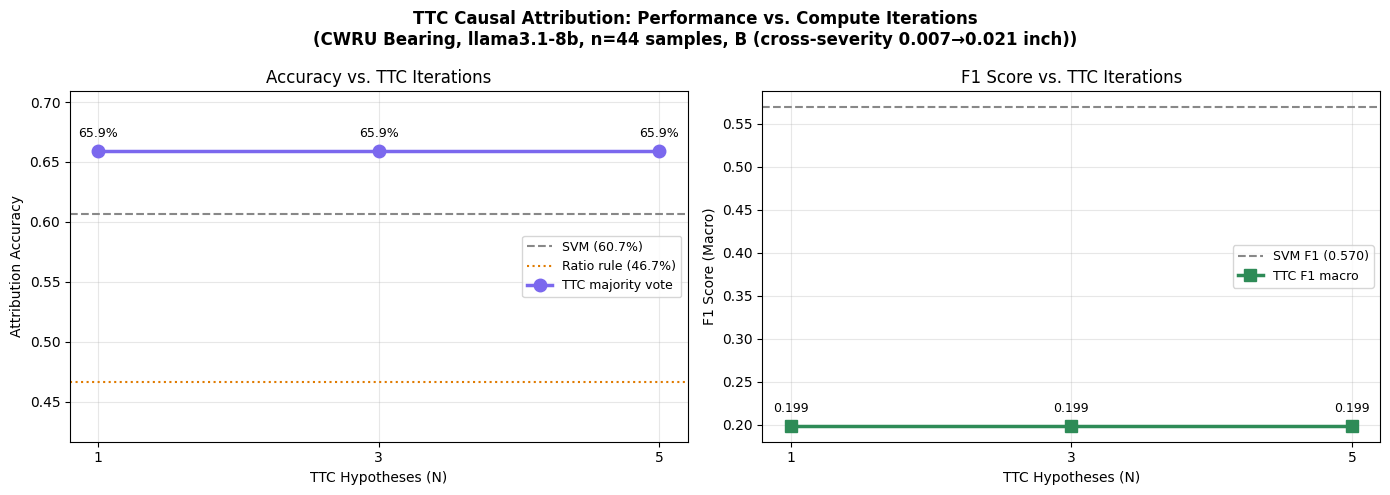

Saved ttc_accuracy_curve_v5_1.png


In [47]:
if not ttc_results:
    print('No TTC results yet — run more samples first.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        'TTC Causal Attribution: Performance vs. Compute Iterations\n'
        f'(CWRU Bearing, {MODEL_NAME}, n={n_cached} samples, {track_id})',
        fontsize=12, fontweight='bold'
    )

    ns      = [n for n in N_ITERATIONS if n in ttc_results]
    accs    = [ttc_results[n]['accuracy'] for n in ns]
    f1s     = [ttc_results[n]['f1'] for n in ns]
    svm_acc = baseline['accuracy']
    svm_f1  = baseline['f1_macro']

    ax = axes[0]
    ax.axhline(svm_acc,   color='#888', linestyle='--', lw=1.5, label=f'SVM ({svm_acc*100:.1f}%)')
    ax.axhline(ratio_acc, color='#E07B00', linestyle=':', lw=1.5, label=f'Ratio rule ({ratio_acc*100:.1f}%)')
    ax.plot(ns, accs, 'o-', color='#7B68EE', lw=2.5, markersize=9, label='TTC majority vote')
    for n, a in zip(ns, accs):
        ax.annotate(f'{a*100:.1f}%', (n, a), textcoords='offset points',
                    xytext=(0, 10), ha='center', fontsize=9)
    ax.set_xlabel('TTC Hypotheses (N)'); ax.set_ylabel('Attribution Accuracy')
    ax.set_title('Accuracy vs. TTC Iterations')
    ax.set_xticks(ns)
    lo = min(svm_acc, ratio_acc, min(accs)) - 0.05
    hi = max(svm_acc, ratio_acc, max(accs)) + 0.05
    ax.set_ylim(max(0, lo), min(1.0, hi))
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    ax2 = axes[1]
    ax2.axhline(svm_f1, color='#888', linestyle='--', lw=1.5, label=f'SVM F1 ({svm_f1:.3f})')
    ax2.plot(ns, f1s, 's-', color='#2E8B57', lw=2.5, markersize=9, label='TTC F1 macro')
    for n, f in zip(ns, f1s):
        ax2.annotate(f'{f:.3f}', (n, f), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9)
    ax2.set_xlabel('TTC Hypotheses (N)'); ax2.set_ylabel('F1 Score (Macro)')
    ax2.set_title('F1 Score vs. TTC Iterations')
    ax2.set_xticks(ns); ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('ttc_accuracy_curve_v5_1.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved ttc_accuracy_curve_v5_1.png')

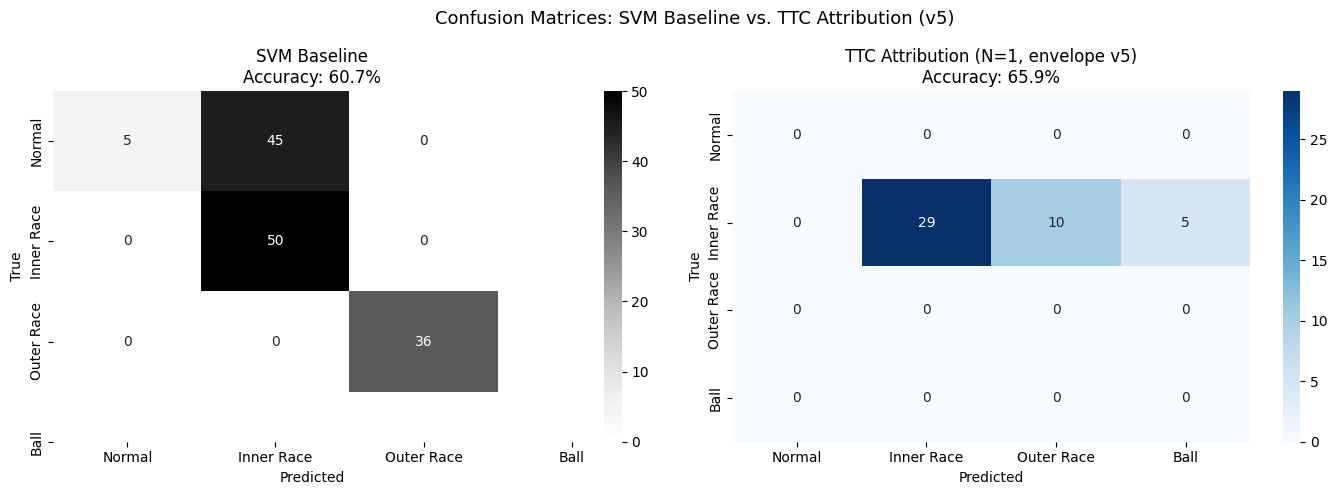

Saved ttc_vs_svm_confusion_v5_1.png


In [48]:
if ttc_results:
    best_n = max(ttc_results, key=lambda n: ttc_results[n]['accuracy'])
    r = ttc_results[best_n]
    cm_ttc = confusion_matrix(r['true'], r['pred'], labels=[0,1,2,3])
    target_names = [LABEL_MAP[i] for i in range(4)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Confusion Matrices: SVM Baseline vs. TTC Attribution (v5)', fontsize=13)

    sns.heatmap(baseline['confusion_matrix'], annot=True, fmt='d', cmap='Greys',
                xticklabels=target_names, yticklabels=target_names, ax=axes[0])
    axes[0].set_title(f'SVM Baseline\nAccuracy: {baseline["accuracy"]*100:.1f}%')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

    sns.heatmap(cm_ttc, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names, ax=axes[1])
    axes[1].set_title(f'TTC Attribution (N={best_n}, envelope v5)\nAccuracy: {r["accuracy"]*100:.1f}%')
    axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

    plt.tight_layout()
    plt.savefig('ttc_vs_svm_confusion_v5_1.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved ttc_vs_svm_confusion_v5_1.png')

In [66]:
print('=== SAMPLE TTC CAUSAL REASONING CHAINS (v5 envelope-enhanced) ===')
shown = 0
override_entries = [(idx, e) for idx, e in cache.items()
                    if majority_vote(e['hypotheses'], N_MAX) != e['svm_pred_name']]
normal_entries   = [(idx, e) for idx, e in cache.items()
                    if majority_vote(e['hypotheses'], N_MAX) == e['svm_pred_name']]
display_order    = override_entries[:2] + normal_entries[:2]

for idx, entry in display_order:
    if shown >= 4:
        break
    if not entry['hypotheses']:
        continue
    vote    = majority_vote(entry['hypotheses'], N_MAX)
    if vote is None:
        continue
    correct = '✓' if vote == entry['true_name'] else '✗'
    action  = '(OVERRIDES SVM)' if vote != entry['svm_pred_name'] else '(agrees with SVM)'
    rep     = next((h for h in entry['hypotheses'] if h.get('fault') == vote), entry['hypotheses'][0])
    print(f'\n[{correct}] True: {entry["true_name"]:12s} | SVM: {entry["svm_pred_name"]:12s} | TTC: {vote} {action}')
    print(f'Confidence  : {rep.get("confidence", "N/A")}')
    print(f'Causal chain: {rep.get("causal_chain", "")[:400]}')
    shown += 1

=== SAMPLE TTC CAUSAL REASONING CHAINS (v5 envelope-enhanced) ===

[✗] True: Inner Race   | SVM: Inner Race   | TTC: Outer Race (OVERRIDES SVM)
Confidence  : 1.0
Causal chain: The Outer Race attribution was determined by Stage 1 of the decision rule, which fired due to the BPFI/BPFO ratio being less than 1.0x, indicating that the fault is likely an Outer Race issue. This conclusion was reached without considering the BPFI sideband ratio.

[✓] True: Inner Race   | SVM: Outer Race   | TTC: Inner Race (OVERRIDES SVM)
Confidence  : 1.0
Causal chain: The Outer Race was ruled out in Stage 1 due to a BPFI/BPFO ratio of 1.08x, which is greater than 1.0x. In Stage 2, the BPFI sideband ratio of 1.32x is less than 3.0x, supporting the attribution of the fault to the Inner Race.

[✗] True: Inner Race   | SVM: Outer Race   | TTC: Outer Race (agrees with SVM)
Confidence  : 1.0
Causal chain: The Outer Race attribution is confirmed due to the BPFI/BPFO ratio being less than 1.0x, which aligns with Sta

## 11. Safety Shield — Experiment 3Deterministic rule-based safety layer blocks unsafe maintenance recommendations.No API calls needed — runs independently of TTC loop.

In [67]:
UNSAFE_PATTERNS = [
    'continue operation',
    'ignore the fault',
    'ignore fault',
    'increase load',
    'increase speed',
    'defer maintenance',
    'no action required',
    'normal operation can continue',
    'keep running',
    'no maintenance needed',
]

SAFE_ACTIONS = [
    'schedule immediate inspection',
    'reduce operational load by 30%',
    'replace bearing within 48 hours',
    'increase vibration monitoring frequency',
    'shut down for maintenance',
    'apply lubrication and monitor',
]

def safety_shield(action_text):
    action_lower = action_text.lower()
    for pattern in UNSAFE_PATTERNS:
        if pattern in action_lower:
            return True, f'Blocked: contains unsafe pattern "{pattern}"'
    return False, 'Action approved'


test_actions = [
    ('continue operation under current load', True),
    ('ignore the fault and monitor next week', True),
    ('increase speed to compensate for vibration', True),
    ('defer maintenance until next quarter', True),
    ('no action required at this time', True),
    ('normal operation can continue safely', True),
    ('schedule immediate inspection of bearing', False),
    ('reduce operational load by 30% immediately', False),
    ('replace bearing within 48 hours', False),
    ('shut down machinery for maintenance', False),
]

print('=== SAFETY SHIELD TEST RESULTS ===\n')
print(f'{"Action":<45} | {"Expected":>10} | {"Result":>10} | {"Pass?":>6}')
print('─' * 80)

correct = 0
for action, expected_block in test_actions:
    blocked, reason = safety_shield(action)
    status = '✓' if blocked == expected_block else '✗'
    if blocked == expected_block:
        correct += 1
    label_exp = 'BLOCK' if expected_block else 'ALLOW'
    label_res = 'BLOCK' if blocked else 'ALLOW'
    print(f'{action[:44]:<45} | {label_exp:>10} | {label_res:>10} | {status:>6}')

print(f'\nShield accuracy: {correct}/{len(test_actions)} ({correct/len(test_actions)*100:.0f}%)')

=== SAFETY SHIELD TEST RESULTS ===

Action                                        |   Expected |     Result |  Pass?
────────────────────────────────────────────────────────────────────────────────
continue operation under current load         |      BLOCK |      BLOCK |      ✓
ignore the fault and monitor next week        |      BLOCK |      BLOCK |      ✓
increase speed to compensate for vibration    |      BLOCK |      BLOCK |      ✓
defer maintenance until next quarter          |      BLOCK |      BLOCK |      ✓
no action required at this time               |      BLOCK |      BLOCK |      ✓
normal operation can continue safely          |      BLOCK |      BLOCK |      ✓
schedule immediate inspection of bearing      |      ALLOW |      ALLOW |      ✓
reduce operational load by 30% immediately    |      ALLOW |      ALLOW |      ✓
replace bearing within 48 hours               |      ALLOW |      ALLOW |      ✓
shut down machinery for maintenance           |      ALLOW |      ALLOW |

## 12. Save Final Results

In [ ]:
final = {
    'ttc_results'      : ttc_results,
    'baseline_accuracy': baseline['accuracy'],
    'baseline_f1'      : baseline['f1_macro'],
    'ratio_accuracy'   : ratio_acc,
    'n_iterations'     : N_ITERATIONS,
    'n_cached'         : n_cached,
    'override_counts'  : override_counts,
    'override_correct' : override_correct,
    'model'            : MODEL_NAME,
    'backend'          : 'SambaNova Cloud',
    'ttc_temperature'  : TTC_TEMP,
    'track'            : track_id,
    'active_severity'  : active_severity,
    'failed_samples'   : failed_samples,
    'feature_version'  : 'v5_1_envelope_spectrum_fault_only_sn',
    'thresholds'       : {'t_low': t_low, 't_high': t_high},
    'n_normal_removed' : n_normal_removed,
}

with open('ttc_results_v5_1_sn.pkl', 'wb') as f:
    pickle.dump(final, f)

print('Saved:')
print('  ttc_results_v5_1_sn.pkl')
print('  ttc_accuracy_curve_v5_1.png')
print('  ttc_vs_svm_confusion_v5_1.png')
print('  ttc_cache_v5_1_sn.pkl')
print(f'\nBackend: SambaNova Cloud (Llama 3.3 70B Instruct)')
print(f'Feature version: v5_1_envelope_spectrum_fault_only_sn')
print(f'Severity: {active_severity} inch (verified from data)')
print(f'Samples: {n_cached} fault-only (Normal excluded per paper methodology)')
print('\nResults ready for paper writing.')